# 02 - VADER Sentiment Demonstration

This notebook demonstrates the VADER rule-based sentiment-analysis
component of the research framework.

VADER is used as the rule-based baseline because it was designed for
sentiment analysis of social-media text.

The demonstration uses synthetic data only.

The results shown in this notebook are demonstrations of the
implementation and must not be interpreted as empirical findings
from Reddit users.

In [75]:
import sys
from pathlib import Path

import pandas as pd

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.vader_sentiment import (
    create_vader_analyser,
    classify_vader_score,
    analyse_text,
    analyse_texts,
)

In [76]:
DATA_PATH = PROJECT_ROOT / "data" / "sample_data.csv"

df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape}")

df.head()

Dataset shape: (9, 3)


,text,game,sentiment
0,The pity system is really helpful and makes pu...,Genshin Impact,Positive
1,The banner rates feel terrible and I spent far...,Genshin Impact,Negative
2,I saved enough primogems for the next character.,Genshin Impact,Neutral
3,I actually like the pity system because I know...,Honkai: Star Rail,Positive
4,The cost of pulls is ridiculous for free to pl...,Honkai: Star Rail,Negative


In [77]:
example_text = "I really love this banner! The character is amazing."

result = analyse_text(example_text)

result

{'negative': 0.0,
 'neutral': 0.411,
 'positive': 0.589,
 'compound': 0.862,
 'sentiment': 'Positive'}

In [78]:
vader_results = analyse_texts(
    df["text"].tolist()
)

vader_results[:3]

[{'negative': 0.319,
  'neutral': 0.491,
  'positive': 0.19,
  'compound': -0.2764,
  'sentiment': 'Negative'},
 {'negative': 0.226,
  'neutral': 0.657,
  'positive': 0.117,
  'compound': -0.3612,
  'sentiment': 'Negative'},
 {'negative': 0.0,
  'neutral': 0.682,
  'positive': 0.318,
  'compound': 0.4215,
  'sentiment': 'Positive'}]

In [79]:
vader_results_df = pd.DataFrame(vader_results)

vader_results_df.head()

,negative,neutral,positive,compound,sentiment
0,0.319,0.491,0.190,-0.2764,Negative
1,0.226,0.657,0.117,-0.3612,Negative
2,0.000,0.682,0.318,0.4215,Positive
3,0.173,0.630,0.197,0.0772,Positive
4,0.154,0.494,0.352,0.4939,Positive


In [80]:
vader_output = pd.concat(
    [
        df.reset_index(drop=True),
        vader_results_df.reset_index(drop=True)
    ],
    axis=1
)

vader_output.head()

,text,game,sentiment,negative,neutral,positive,compound,sentiment
0,The pity system is really helpful and makes pu...,Genshin Impact,Positive,0.319,0.491,0.190,-0.2764,Negative
1,The banner rates feel terrible and I spent far...,Genshin Impact,Negative,0.226,0.657,0.117,-0.3612,Negative
2,I saved enough primogems for the next character.,Genshin Impact,Neutral,0.000,0.682,0.318,0.4215,Positive
3,I actually like the pity system because I know...,Honkai: Star Rail,Positive,0.173,0.630,0.197,0.0772,Positive
4,The cost of pulls is ridiculous for free to pl...,Honkai: Star Rail,Negative,0.154,0.494,0.352,0.4939,Positive


In [81]:
vader_output = vader_output.rename(
    columns={"sentiment": "vader_sentiment"}
)

In [82]:
vader_results_df = pd.DataFrame(vader_results)

vader_results_df = vader_results_df.rename(
    columns={"sentiment": "vader_sentiment"}
)

vader_output = pd.concat(
    [
        df.reset_index(drop=True),
        vader_results_df.reset_index(drop=True)
    ],
    axis=1
)

# Remove any duplicate column names
vader_output = vader_output.loc[
    :, ~vader_output.columns.duplicated()
]

vader_output.head()

,text,game,sentiment,negative,neutral,positive,compound,vader_sentiment
0,The pity system is really helpful and makes pu...,Genshin Impact,Positive,0.319,0.491,0.190,-0.2764,Negative
1,The banner rates feel terrible and I spent far...,Genshin Impact,Negative,0.226,0.657,0.117,-0.3612,Negative
2,I saved enough primogems for the next character.,Genshin Impact,Neutral,0.000,0.682,0.318,0.4215,Positive
3,I actually like the pity system because I know...,Honkai: Star Rail,Positive,0.173,0.630,0.197,0.0772,Positive
4,The cost of pulls is ridiculous for free to pl...,Honkai: Star Rail,Negative,0.154,0.494,0.352,0.4939,Positive


In [83]:
vader_output["vader_sentiment"].value_counts()

vader_sentiment
Negative    4
Positive    3
Neutral     2
Name: count, dtype: int64

In [84]:
vader_output["vader_sentiment"].value_counts(normalize=True)

vader_sentiment
Negative    0.444444
Positive    0.333333
Neutral     0.222222
Name: proportion, dtype: float64

## VADER Sentiment Distribution

The following visualisation demonstrates the distribution of VADER
sentiment classifications across the synthetic demonstration dataset.

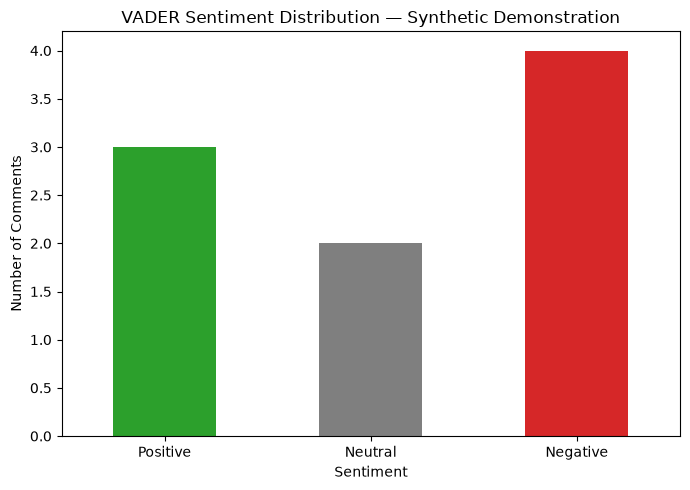

In [85]:
import matplotlib.pyplot as plt

sentiment_counts = (
    vader_output["vader_sentiment"]
    .value_counts()
    .reindex(["Positive", "Neutral", "Negative"])
)

sentiment_counts.plot(
    kind="bar",
    color=["#2ca02c", "#7f7f7f", "#d62728"],
    figsize=(7, 5)
)

plt.title("VADER Sentiment Distribution — Synthetic Demonstration")
plt.xlabel("Sentiment")
plt.ylabel("Number of Comments")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [86]:
test_scores = [
    -0.8,
    -0.05,
    0.0,
    0.04,
    0.05,
    0.8
]

threshold_tests = pd.DataFrame({
    "compound_score": test_scores,
    "classification": [
        classify_vader_score(score)
        for score in test_scores
    ]
})

threshold_tests

,compound_score,classification
0,-0.80,Negative
1,-0.05,Negative
2,0.00,Neutral
3,0.04,Neutral
4,0.05,Positive
5,0.80,Positive


## Interpretation

The notebook demonstrates the implementation of the VADER rule-based
baseline.

The implementation successfully:

1. Creates a VADER sentiment analyser.
2. Calculates VADER sentiment scores.
3. Converts compound scores into Positive, Neutral and Negative labels.
4. Processes multiple text entries.
5. Produces a sentiment distribution.
6. Provides visualisation of the demonstration results.
7. Tests the classification thresholds.

The dataset used in this notebook is synthetic demonstration data.
Consequently, these results must not be interpreted as empirical
findings about Reddit users or the selected gacha-game communities.

The VADER implementation is intended to provide a baseline for future
empirical evaluation using an appropriately authorised research
dataset.